<div class="alert alert-block alert-success">
<b>Comentario general del revisor</b> <a class="tocSkip"></a><br />
Status del proyecto: <b>Aprobado</b>
    

</div>


¡Hola!<br />
Soy **Francisco Cortés**, estoy contento de revisar tu proyecto y ser parte de tu proceso de aprendizaje.
A lo largo del texto, haré algunas observaciones sobre mejoras en el código y también haré comentarios sobre tus percepciones sobre el tema. Si existe algún error en el código, no te preocupes, estoy aquí para ayudarte a mejorarlo, en la primera iteración te lo señalaré para que tengas la oportunidad de corregirlo, pero si aún no encuentras una solución para esta tarea, te daré una pista más precisa en la próxima iteración y también algunos ejemplos prácticos. Estaré abierto a retroalimentación y discusiones sobre el tema.<br />
Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o borres**.
Revisaré cuidadosamente tu código para comprobar que se han cumplido con los requisitos y te proporcionaré mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si la ejecución fue perfecta succesfully.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existe alguna recomendación para que tu código mejore.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario del revisor</b> <a class="tocSkip"></a>

Si existen correcciones necesarias para cumplir con los requisitos. El trabajo no puede ser aceptado si hay alguna caja roja.
</div>

Puedes responderme de la siguiente manera:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>


# ¿Cuál es la mejor tarifa?

Trabajas como analista para el operador de telecomunicaciones Megaline. La empresa ofrece a sus clientes dos tarifas de prepago, Surf y Ultimate. El departamento comercial quiere saber cuál de las tarifas genera más ingresos para poder ajustar el presupuesto de publicidad.

Vas a realizar un análisis preliminar de las tarifas basado en una selección de clientes relativamente pequeña. Tendrás los datos de 500 clientes de Megaline: quiénes son los clientes, de dónde son, qué tarifa usan, así como la cantidad de llamadas que hicieron y los mensajes de texto que enviaron en 2018. Tu trabajo es analizar el comportamiento de los clientes y determinar qué tarifa de prepago genera más ingresos.

[Te proporcionamos algunos comentarios para orientarte mientras completas este proyecto. Pero debes asegurarte de eliminar todos los comentarios entre corchetes antes de entregar tu proyecto.]

[Antes de sumergirte en el análisis de datos, explica por tu propia cuenta el propósito del proyecto y las acciones que planeas realizar.]

[Ten en cuenta que estudiar, modificar y analizar datos es un proceso iterativo. Es normal volver a los pasos anteriores y corregirlos/ampliarlos para permitir nuevos pasos.]

## Inicialización

In [1]:
# Cargar todas las librerías necesarias para el proyecto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns




## Cargar datos

In [2]:
# Carga los archivos de datos en diferentes DataFrames
df_users = pd.read_csv("/datasets/megaline_users.csv")
df_calls = pd.read_csv("/datasets/megaline_calls.csv")
df_messages = pd.read_csv("/datasets/megaline_messages.csv")
df_internet = pd.read_csv("/datasets/megaline_internet.csv")
df_plans = pd.read_csv("/datasets/megaline_plans.csv")



## Preparar los datos

## Tarifas

In [3]:
# Imprime la información general/resumida sobre el DataFrame de las tarifas
df_plans.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      object 
dtypes: float64(2), int64(5), object(1)
memory usage: 256.0+ bytes


In [4]:
# Imprime una muestra de los datos para las tarifas
print(df_plans.head())



   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


Con la informacion general se pueden ver los tipos de datos que a mi parecer son adecuados, y observando la tabla es informacion sobre las tarifas de cada plan, solo hay 2 planes por lo tanto solo hay 2 renglones cada una con su propia tarifa

## Corregir datos

In [5]:
#No veo errores en la tabla df_plans

## Enriquecer los datos

In [6]:
#No encuentro nada para agregarle

## Usuarios/as

In [7]:
# Imprime la información general/resumida sobre el DataFrame de usuarios
df_users.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   first_name  500 non-null    object
 2   last_name   500 non-null    object
 3   age         500 non-null    int64 
 4   city        500 non-null    object
 5   reg_date    500 non-null    object
 6   plan        500 non-null    object
 7   churn_date  34 non-null     object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [8]:
# Imprime una muestra de datos para usuarios
print(df_users.head())




   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    Jenkins   52                          Tulsa, OK MSA   
4     1004    Leonila   Thompson   40        Seattle-Tacoma-Bellevue, WA MSA   

     reg_date      plan churn_date  
0  2018-12-24  ultimate        NaN  
1  2018-08-13      surf        NaN  
2  2018-10-21      surf        NaN  
3  2018-01-28      surf        NaN  
4  2018-05-23      surf        NaN  


En la tabla de usuarios podemos ver los datos personales del usuario, la fecha de registro y el nombre del plan, lo que le podemos cambiar a la tabla es el tipo de dato de las fechas, cambiarlas a tipo fecha y tambien el nombre de la columna plan podemos homologarla a "plan_name"

### Corregir los datos

In [9]:

#Renombramos el nombre de la columna "plan" por "plan_name"
df_users.rename(columns={'plan':'plan_name'}, inplace=True)

#Cambiamos el tipo de dato a tipo fecha de las columnas "reg_date" y "churn_date"
df_users['reg_date'] = pd.to_datetime(df_users['reg_date'])
df_users['churn_date'] = pd.to_datetime(df_users['churn_date'])

#visualizamos los cambios
df_users.info()
print(df_users.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   first_name  500 non-null    object        
 2   last_name   500 non-null    object        
 3   age         500 non-null    int64         
 4   city        500 non-null    object        
 5   reg_date    500 non-null    datetime64[ns]
 6   plan_name   500 non-null    object        
 7   churn_date  34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB
   user_id first_name  last_name  age                                   city  \
0     1000   Anamaria      Bauer   45  Atlanta-Sandy Springs-Roswell, GA MSA   
1     1001     Mickey  Wilkerson   28        Seattle-Tacoma-Bellevue, WA MSA   
2     1002     Carlee    Hoffman   36   Las Vegas-Henderson-Paradise, NV MSA   
3     1003   Reynaldo    J

### Enriquecer los datos

In [10]:
#No encontre opciones para enriqueser esta tabla

## Llamadas

In [11]:
# Imprime la información general/resumida sobre el DataFrame de las llamadas
df_calls.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  object 
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  object 
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 4.2+ MB


In [12]:
# Imprime una muestra de datos para las llamadas
print(df_calls.head())


         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


Aqui podemos ver la informacion de cada llamada individualmente, en esta tabla se puede mejorar el nombre de la columna "id" se puede cambiar por "call_id" para mejorar su descripcion y el tipo de dato de la columna "call_date" cambiarlo a tipo fecha, y para cuestion de analisis puedo agregar una columna "month" para facilitar futuros analisis

### Corregir los datos

In [13]:

#Renombramos el nombre de la columna "id" por "call_id"
df_calls.rename(columns={'id':'call_id'}, inplace=True)

#Cambiamos el tipo de dato a tipo fecha de la columna "call_date"
df_calls['call_date'] = pd.to_datetime(df_calls['call_date'])

#Visualisamos los cambios
df_calls.info()
print(df_calls.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   call_id    137735 non-null  object        
 1   user_id    137735 non-null  int64         
 2   call_date  137735 non-null  datetime64[ns]
 3   duration   137735 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.2+ MB
    call_id  user_id  call_date  duration
0   1000_93     1000 2018-12-27      8.52
1  1000_145     1000 2018-12-27     13.66
2  1000_247     1000 2018-12-27     14.48
3  1000_309     1000 2018-12-28      5.76
4  1000_380     1000 2018-12-30      4.22


### Enriquecer los datos

Aqui agregaremos una nueva columna llamada "month" extraida de la columna "call_date"

In [14]:
#Agregamos la nueva columna "month"
df_calls['month'] = df_calls['call_date'].dt.month

#Visualizamos los cambios
print(df_calls.head())



    call_id  user_id  call_date  duration  month
0   1000_93     1000 2018-12-27      8.52     12
1  1000_145     1000 2018-12-27     13.66     12
2  1000_247     1000 2018-12-27     14.48     12
3  1000_309     1000 2018-12-28      5.76     12
4  1000_380     1000 2018-12-30      4.22     12


## Mensajes

In [15]:
# Imprime la información general/resumida sobre el DataFrame de los mensajes
df_messages.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            76051 non-null  object
 1   user_id       76051 non-null  int64 
 2   message_date  76051 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.7+ MB


In [16]:
# Imprime una muestra de datos para los mensajes
print(df_messages.head())



         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


Aqui podemos ver la informacion de cada mensaje individualmente, en esta tabla se puede mejorar el nombre de la columna "id" se puede cambiar por "message_id" para mejorar su descripcion y el tipo de dato de la columna "message_date" cambiarlo a tipo fecha, y para cuestion de analisis puedo agregar una columna "month" para facilitar futuros analisis

### Corregir los datos

In [17]:

#Renombramos el nombre de la columna "id" por "message_id"
df_messages.rename(columns={'id':'message_id'}, inplace=True)

#Cambiamos el tipo de dato a tipo fecha de la columna "message_date"
df_messages['message_date'] = pd.to_datetime(df_messages['message_date'])

#Visualisamos los cambios
df_messages.info()
print(df_messages.head())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   message_id    76051 non-null  object        
 1   user_id       76051 non-null  int64         
 2   message_date  76051 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 1.7+ MB
  message_id  user_id message_date
0   1000_125     1000   2018-12-27
1   1000_160     1000   2018-12-31
2   1000_223     1000   2018-12-31
3   1000_251     1000   2018-12-27
4   1000_255     1000   2018-12-26


### Enriquecer los datos

Aqui agregaremos una nueva columna llamada "month" extraida de la columna "message_date"

In [18]:

#Agregamos la nueva columna "month"
df_messages['month'] = df_messages['message_date'].dt.month

#Visualizamos los cambios
print(df_messages.head())



  message_id  user_id message_date  month
0   1000_125     1000   2018-12-27     12
1   1000_160     1000   2018-12-31     12
2   1000_223     1000   2018-12-31     12
3   1000_251     1000   2018-12-27     12
4   1000_255     1000   2018-12-26     12


## Internet

In [19]:
# Imprime la información general/resumida sobre el DataFrame de internet
df_internet.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  object 
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  object 
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.2+ MB


In [20]:
# Imprime una muestra de datos para el tráfico de internet
print(df_internet.head())



         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


Aqui podemos ver la informacion de cada sesion de datos individualmente, en esta tabla se puede mejorar el nombre de la columna "id" se puede cambiar por "internet_session_id" para mejorar su descripcion y el tipo de dato de la columna "session_date" cambiarlo a tipo fecha, y para cuestion de analisis puedo agregar una columna "month" para facilitar futuros analisis

### Corregir los datos

In [21]:
#Renombramos el nombre de la columna "id" por "internet_session_id"
df_internet.rename(columns={'id':'internet_session_id'}, inplace=True)

#Cambiamos el tipo de dato a tipo fecha de la columna "session_date"
df_internet['session_date'] = pd.to_datetime(df_internet['session_date'])

#Visualisamos los cambios
df_internet.info()
print(df_internet.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   internet_session_id  104825 non-null  object        
 1   user_id              104825 non-null  int64         
 2   session_date         104825 non-null  datetime64[ns]
 3   mb_used              104825 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 3.2+ MB
  internet_session_id  user_id session_date  mb_used
0             1000_13     1000   2018-12-29    89.86
1            1000_204     1000   2018-12-31     0.00
2            1000_379     1000   2018-12-28   660.40
3            1000_413     1000   2018-12-26   270.99
4            1000_442     1000   2018-12-27   880.22


### Enriquecer los datos

In [22]:
#Agregamos la nueva columna "month"
df_internet['month'] = df_internet['session_date'].dt.month

#Visualizamos los cambios
print(df_internet.head())



  internet_session_id  user_id session_date  mb_used  month
0             1000_13     1000   2018-12-29    89.86     12
1            1000_204     1000   2018-12-31     0.00     12
2            1000_379     1000   2018-12-28   660.40     12
3            1000_413     1000   2018-12-26   270.99     12
4            1000_442     1000   2018-12-27   880.22     12


## Estudiar las condiciones de las tarifas

In [23]:
# Imprime las condiciones de la tarifa y asegúrate de que te quedan claras
print(df_plans)




   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>

Los datos fueron revisados y modificados apropiadamente, ahora se puede empezar a trabajar con ellos comodamente
</div>


## Agregar datos por usuario

[Ahora que los datos están limpios, agrega los datos por usuario y por periodo para que solo haya un registro por usuario y por periodo. Esto facilitará mucho el análisis posterior.]

In [24]:
# Calcula el número de llamadas hechas por cada usuario al mes. Guarda el resultado.
# Se agrupan los datos y hace un conteo de todos los ids de las llamadas, al final resetea el index 
# Para obtener un DataFrame con los indices correctos
calls_per_user = df_calls.groupby(["user_id","month"])["call_id"].count().reset_index()

#Se renombra la columna "call_id" por "calls_count" porque se entiende mejor
calls_per_user.columns = ["user_id", "month", "calls_count"]

#Se visualiza la tabla "call_per_user"
print(calls_per_user)



      user_id  month  calls_count
0        1000     12           16
1        1001      8           27
2        1001      9           49
3        1001     10           65
4        1001     11           64
...       ...    ...          ...
2253     1498     12           39
2254     1499      9           41
2255     1499     10           53
2256     1499     11           45
2257     1499     12           65

[2258 rows x 3 columns]


In [25]:
# Calcula la cantidad de minutos usados por cada usuario al mes. Guarda el resultado.
# Se agrupan los datos y hace la suma la columna "duration" para obtener el total de minutos por usuario
# y se resesetea el index para obtener un DataFrame con los indices correctos
minutes_per_user = df_calls.groupby(["user_id","month"])["duration"].sum().reset_index()

#Se visualiza la tabla "minutes_per_user"
print(minutes_per_user)


      user_id  month  duration
0        1000     12    116.83
1        1001      8    171.14
2        1001      9    297.69
3        1001     10    374.11
4        1001     11    404.59
...       ...    ...       ...
2253     1498     12    324.77
2254     1499      9    330.37
2255     1499     10    363.28
2256     1499     11    288.56
2257     1499     12    468.10

[2258 rows x 3 columns]


In [26]:
# Calcula el número de mensajes enviados por cada usuario al mes. Guarda el resultado.
# Se agrupan los datos y hace un conteo de todos los ids de los mensajes, al final resetea el index 
# para obtener un DataFrame con los indices correctos
messages_per_user = df_messages.groupby(["user_id","month"])["message_id"].count().reset_index()

#Se renombra la columna "message_id" por "message_count" porque se entiende mejor
messages_per_user.columns = ["user_id", "month", "messages_count"]

#Se visualiza la tabla "messages_per_user"
print(messages_per_user)


      user_id  month  messages_count
0        1000     12              11
1        1001      8              30
2        1001      9              44
3        1001     10              53
4        1001     11              36
...       ...    ...             ...
1801     1496      9              21
1802     1496     10              18
1803     1496     11              13
1804     1496     12              11
1805     1497     12              50

[1806 rows x 3 columns]


In [27]:
# Calcula el volumen del tráfico de Internet usado por cada usuario al mes. Guarda el resultado.
# Se agrupan los datos y hace la suma la columna "mb_used" para obtener el total mb usados por usuario
# y se resesetea el index para obtener un DataFrame con los indices correctos
internet_per_user = df_internet.groupby(["user_id","month"])["mb_used"].sum().reset_index()

#Se visualiza la tabla "internet_per_user"
print(internet_per_user)


      user_id  month   mb_used
0        1000     12   1901.47
1        1001      8   6919.15
2        1001      9  13314.82
3        1001     10  22330.49
4        1001     11  18504.30
...       ...    ...       ...
2272     1498     12  23137.69
2273     1499      9  12984.76
2274     1499     10  19492.43
2275     1499     11  16813.83
2276     1499     12  22059.21

[2277 rows x 3 columns]


In [28]:
# Fusiona los datos de llamadas, minutos, mensajes e Internet con base en user_id y month
# Aqui tenemos que hacer merge de forma iterativa para unir los 4 dataframes con base en user_id y month
# en formato outer para no perder informacion
all_per_user = calls_per_user.merge(minutes_per_user, on = ['user_id', 'month'], how = 'outer')
all_per_user = all_per_user.merge(messages_per_user, on = ['user_id', 'month'], how = 'outer')
all_per_user = all_per_user.merge(internet_per_user, on = ['user_id', 'month'], how = 'outer')

#Se visualiza la tabla "all_per_user"
print(all_per_user)


      user_id  month  calls_count  duration  messages_count   mb_used
0        1000     12         16.0    116.83            11.0   1901.47
1        1001      8         27.0    171.14            30.0   6919.15
2        1001      9         49.0    297.69            44.0  13314.82
3        1001     10         65.0    374.11            53.0  22330.49
4        1001     11         64.0    404.59            36.0  18504.30
...       ...    ...          ...       ...             ...       ...
2288     1349     12          NaN       NaN            61.0  13039.91
2289     1361      5          NaN       NaN             2.0   1519.69
2290     1482     10          NaN       NaN             2.0       NaN
2291     1108     12          NaN       NaN             NaN    233.17
2292     1311      6          NaN       NaN             NaN   1498.83

[2293 rows x 6 columns]


In [29]:
# Añade la información de la tarifa
# Se hace un merge para agregar la columna de "plan_name" de la tabla de "df_users"
# en formato left para solo traer la infomacion de la columna "plan_name"
all_per_user = all_per_user.merge(df_users[['user_id', 'plan_name']], on='user_id', how='left')

#Se realiza un segundo merge para agregar todos los demas datos de la tarifa de la tabla "df_plans"
all_per_user = all_per_user.merge(df_plans, on='plan_name', how='left')

# Una ves que ya esta completo el DataFrame general "all_per_user" se realiza una limpieza de los datos para remplazar
# los datos NaN por 0s
all_per_user = all_per_user.fillna(0)

# Se visualiza el DataFrame "all_per_user"
print(all_per_user)




      user_id  month  calls_count  duration  messages_count   mb_used  \
0        1000     12         16.0    116.83            11.0   1901.47   
1        1001      8         27.0    171.14            30.0   6919.15   
2        1001      9         49.0    297.69            44.0  13314.82   
3        1001     10         65.0    374.11            53.0  22330.49   
4        1001     11         64.0    404.59            36.0  18504.30   
...       ...    ...          ...       ...             ...       ...   
2288     1349     12          0.0      0.00            61.0  13039.91   
2289     1361      5          0.0      0.00             2.0   1519.69   
2290     1482     10          0.0      0.00             2.0      0.00   
2291     1108     12          0.0      0.00             0.0    233.17   
2292     1311      6          0.0      0.00             0.0   1498.83   

     plan_name  messages_included  mb_per_month_included  minutes_included  \
0     ultimate               1000            

In [30]:
# Calcula el ingreso mensual para cada usuario
# Crearemos una funcion general que reciba un renglon completo del DataFrame "all_per_user"
# Y calcule el total de minutos, mensajes y mb(entre 1024 para hace el calculo en GB) extras
# tambien realice el calculo de cuanto dinero extra se pagó por esos excedentes

def calcular_ingresos(row):
  plan = df_plans[df_plans["plan_name"] == row["plan_name"]].iloc[0]
  extra_minutes = max(row["duration"] - plan["minutes_included"], 0)
  extra_messages = max(row["messages_count"] - plan["messages_included"], 0)
  extra_data = max(row["mb_used"] - plan["mb_per_month_included"], 0) / 1024
  ingresos = (plan["usd_monthly_pay"] + extra_minutes*plan["usd_per_minute"]
                      + extra_messages*plan["usd_per_message"]
                      + np.ceil(extra_data)*plan["usd_per_gb"])
  
  return ingresos

# Aqui mandamos llamar a la funcion creada con ayuda de apply con axis=1 para que lo realice horizontalmente
# y el resultado lo pondremos en una nueva columna llamada "revenue"
all_per_user["revenue"] = all_per_user.apply(calcular_ingresos, axis=1)

# Se visualiza el DataFrame "all_per_user"
print(all_per_user.head())




   user_id  month  calls_count  duration  messages_count   mb_used plan_name  \
0     1000     12         16.0    116.83            11.0   1901.47  ultimate   
1     1001      8         27.0    171.14            30.0   6919.15      surf   
2     1001      9         49.0    297.69            44.0  13314.82      surf   
3     1001     10         65.0    374.11            53.0  22330.49      surf   
4     1001     11         64.0    404.59            36.0  18504.30      surf   

   messages_included  mb_per_month_included  minutes_included  \
0               1000                  30720              3000   
1                 50                  15360               500   
2                 50                  15360               500   
3                 50                  15360               500   
4                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute  revenue  
0               70           7             0.01      

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

Buena manera de agregar los datos por usuario, ahora tenemos columnas extras que nos ayudarán con el analisis posterior
</div>


## Estudia el comportamiento de usuario

### Llamadas

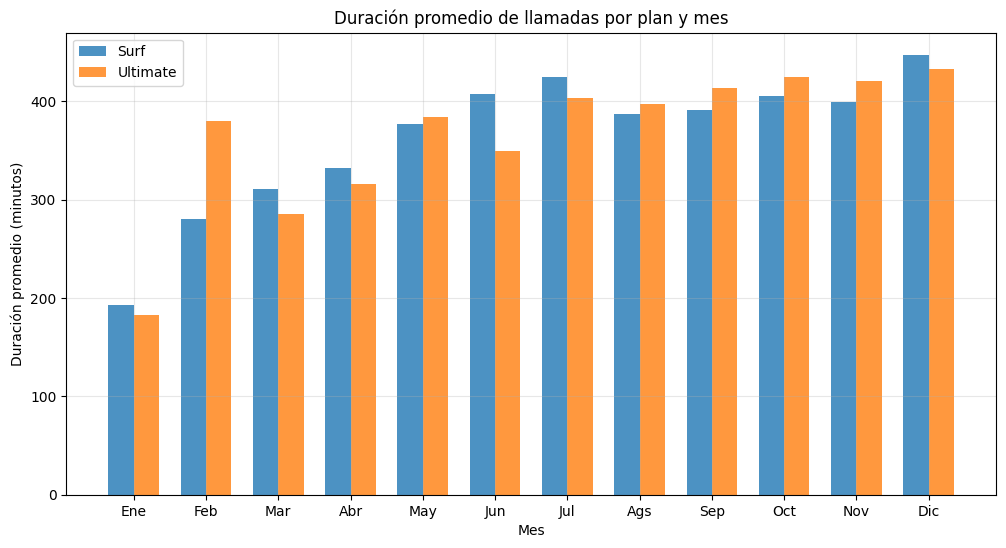

In [31]:
# Compara la duración promedio de llamadas por cada plan y por cada mes. Traza un gráfico de barras para visualizarla.

# Agrupamos por plan y mes y calculamos el promedio de duration
duration_by_plan_month = all_per_user.groupby(['plan_name', 'month'])['duration'].mean().reset_index()

# Creamos la configuración del tamaño del gráfico de barras para comparar duración promedio
plt.figure(figsize=(12, 6))

# Separamos datos por plan ya que vamos a graficar barras dobles (surf y ultimate)
surf_data = duration_by_plan_month[duration_by_plan_month['plan_name'] == 'surf']
ultimate_data = duration_by_plan_month[duration_by_plan_month['plan_name'] == 'ultimate']

# Creamos posiciones para las barras para que el rango sea del 0-11 (12 meses)
x = np.arange(len(surf_data['month']))

#configuramos el ancho de la barra
width = 0.35

# creamos las barras, una para surf y otra para ultimate separados por una anchura de la barra (2 veces media anchura)
plt.bar(x - width/2, surf_data['duration'], width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_data['duration'], width, label='Ultimate', alpha=0.8)

# Personalizamos el gráfico
plt.xlabel('Mes')
plt.ylabel('Duración promedio (minutos)')
plt.title('Duración promedio de llamadas por plan y mes')

#agregamos los nombres de cada mes en el eje x
plt.xticks(x, ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ags','Sep','Oct','Nov','Dic'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


########CONCLUSIONES######
# En la grafica podemos ver que e promedio de los minutos de ambos planes son muy similares, incluso algunos meses
# el plan Surf tiene promedios ligeramente mas altos, al parecer los clientes del plan ultimate
# no estan aprovechando sus 3000 minutos que tienen incluidos en las llamadas



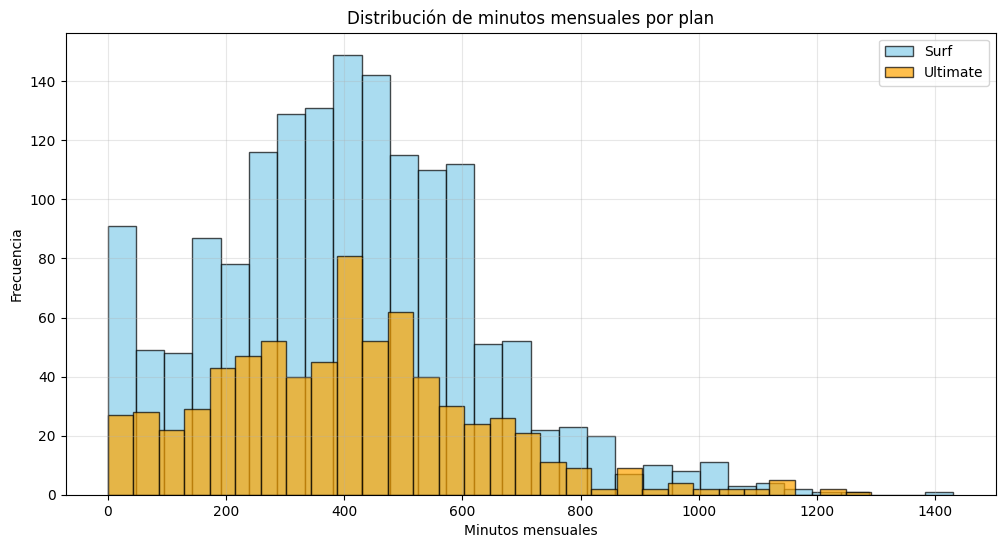

In [32]:
# Compara el número de minutos mensuales que necesitan los usuarios de cada plan. Traza un histograma.
# Separamos datos por plan y traemos la duracion
surf_minutes = all_per_user[all_per_user['plan_name'] == 'surf']['duration']
ultimate_minutes = all_per_user[all_per_user['plan_name'] == 'ultimate']['duration']

# Creamos la configuración del tamaño del gráfico histograma para comparar duración
# que necesitan los usuarios en cada plan
plt.figure(figsize=(12, 6))

# Creamos histogramas superpuestos (azul=suft, naranja=ultimate)
plt.hist(surf_minutes, bins=30, alpha=0.7, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_minutes, bins=30, alpha=0.7, label='Ultimate', color='orange', edgecolor='black')

# Personalizamos el gráfico
plt.xlabel('Minutos mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de minutos mensuales por plan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

########CONCLUSIONES######
# En la grafica se aprecia que las frecuencias mas altas son del plan surf pero puede deverse a que hay mas personas
# que contratan ese plan, tambien podemos ver que en ambos planes la moda esta en 400 aproximadamente
# y que estan sesgados a la derecha.
# No hay mucha significancia en el comportamiento en cuestion de llamadas si contratan un plan u otro


In [33]:
# Calcula la media y la varianza de la duración mensual de llamadas.
# Agrupamos por plan y mes y calculamos la media y la varianza de duration
stats_by_plan_month = all_per_user.groupby(['plan_name', 'month'])['duration'].agg(['mean', 'var']).reset_index()

# Visualizamos la tabla
print("Estadísticas por plan y mes:")
print(stats_by_plan_month)



Estadísticas por plan y mes:
   plan_name  month        mean           var
0       surf      1  192.840000  14795.440200
1       surf      2  280.851111  46959.219961
2       surf      3  310.970000  31821.317991
3       surf      4  332.380000  45615.666796
4       surf      5  377.053247  53282.922217
5       surf      6  407.208866  40758.661193
6       surf      7  424.523223  54434.184064
7       surf      8  387.169630  48616.061790
8       surf      9  390.992062  41580.494645
9       surf     10  405.692363  46731.430317
10      surf     11  399.599823  46105.085924
11      surf     12  447.475283  56983.247423
12  ultimate      1  183.162500  14991.369958
13  ultimate      2  379.861429  68540.288348
14  ultimate      3  285.701667  54273.917252
15  ultimate      4  316.508095  31057.727496
16  ultimate      5  383.664828  39290.610940
17  ultimate      6  349.811064  37923.360514
18  ultimate      7  403.767288  64844.426958
19  ultimate      8  397.274789  47680.189425
20  u

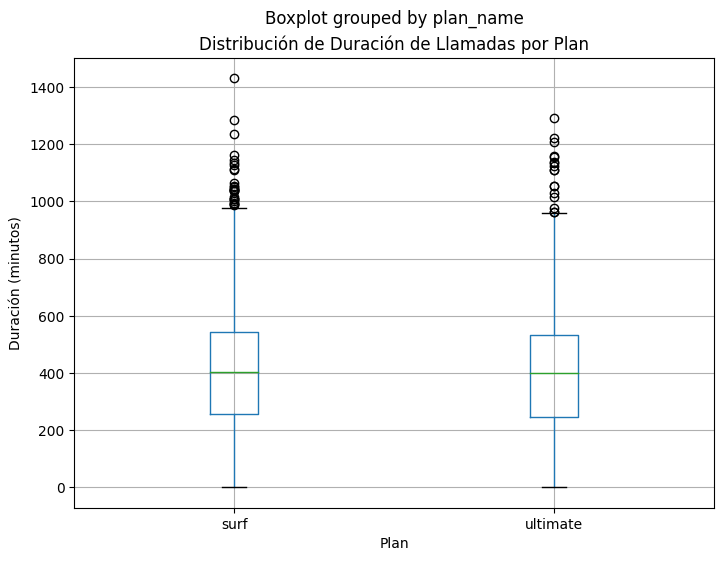

In [34]:
# Traza un diagrama de caja para visualizar la distribución de la duración mensual de llamadas

# Diagrama de caja para comparar la duración de llamadas entre planes
plt.figure(figsize=(8, 6))
all_per_user.boxplot(column='duration', by='plan_name', ax=plt.gca())
plt.title('Distribución de Duración de Llamadas por Plan')
plt.xlabel('Plan')
plt.ylabel('Duración (minutos)')
plt.show()


CONCLUSIONES: No hay mucha diferencia en el comportamiento de las llamadas respecto a un plan u otro, el comportamiento es relativamente similar. Pero debido al limite mas pequeño de surf, muchas personas estan pagando minutos extras, posiblemente a dichas personas les convenga cambiarse al plan ultimate

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!<br/>

Buena manera de mostrar los datos, se puede ver claramente las tendencias de cada uno de los planes gracias a las gráficas que has utilizado con las cuales podemos revisar aspectos diferentes de los planes
</div>


### Mensajes

Estadísticas de mensajes - Plan Surf:
Media: 31.16
Mediana: 24.00
Desviación estándar: 33.57

Estadísticas de mensajes - Plan Ultimate:
Media: 37.55
Mediana: 30.00
Desviación estándar: 34.77


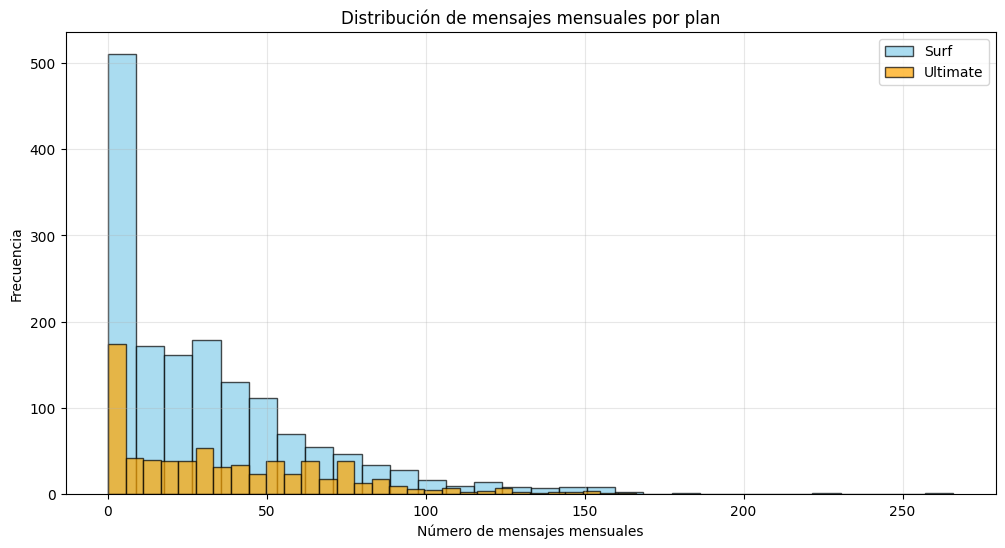

In [35]:
# Comprara el número de mensajes que tienden a enviar cada mes los usuarios de cada plan
# Filtramos por tipo de plan, traemos la columna del numero de mensajes y lo asignamos a su respectiva variable
surf_messages = all_per_user[all_per_user['plan_name'] == 'surf']['messages_count']
ultimate_messages = all_per_user[all_per_user['plan_name'] == 'ultimate']['messages_count']

# Imprimimos las estadisticas numericas
print("Estadísticas de mensajes - Plan Surf:")
print(f"Media: {surf_messages.mean():.2f}")
print(f"Mediana: {surf_messages.median():.2f}")
print(f"Desviación estándar: {surf_messages.std():.2f}")

print("\nEstadísticas de mensajes - Plan Ultimate:")
print(f"Media: {ultimate_messages.mean():.2f}")
print(f"Mediana: {ultimate_messages.median():.2f}")
print(f"Desviación estándar: {ultimate_messages.std():.2f}")

# Una vez teniendo el numero de mensajes separados por plan, creamos un histograma para compararlos mejor
plt.figure(figsize=(12, 6))
plt.hist(surf_messages, bins=30, alpha=0.7, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_messages, bins=30, alpha=0.7, label='Ultimate', color='orange', edgecolor='black')
plt.xlabel('Número de mensajes mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de mensajes mensuales por plan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


########CONCLUSIONES######
# En la gráfico se puede observar un comportamiento muy similar en los mensajes de ambos planes
# Hay mas frecuencia en los mensajes de surf pero es porque mas gente contrata dicho plan
# En las estadisticas calculadas podemos ver como la media, mediana y desviacion estandar son
# un poco mayores en el plan ultimate
# En la grafica tambien podemos observar que el muchos clientes del plan surf se exceden en sus limites de mensajes
# por mucho, esos son clientes potenciales para cambiarse al plan ultimate


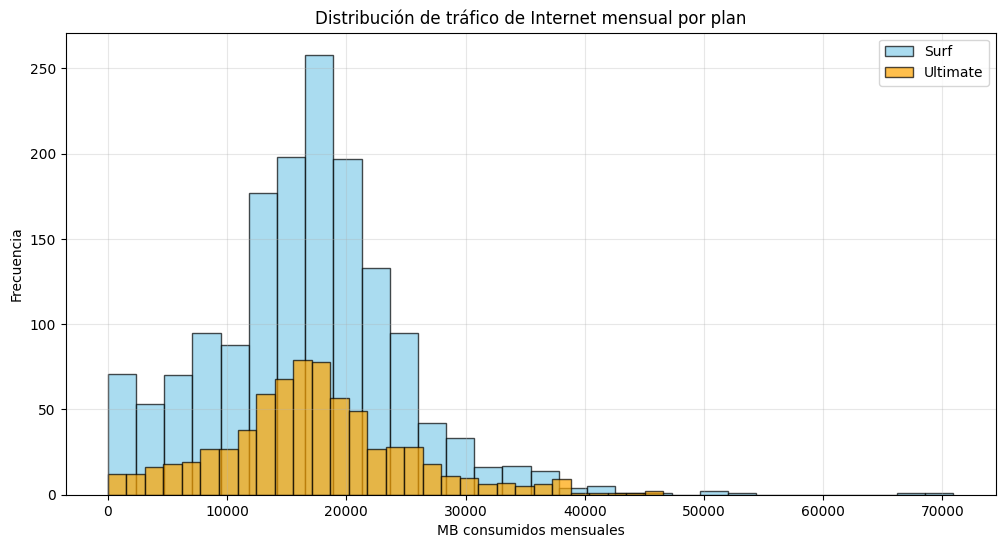

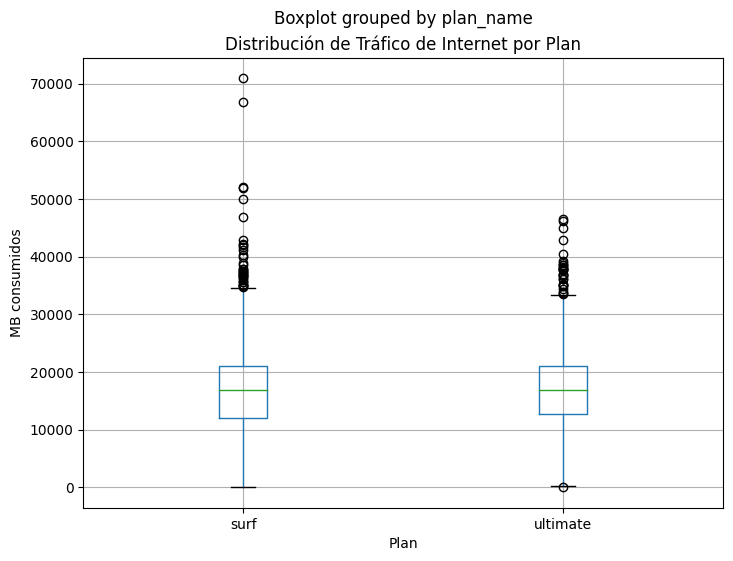

Estadísticas de Internet - Plan Surf:
Media: 16558.28 MB
Mediana: 16829.31 MB

Estadísticas de Internet - Plan Ultimate:
Media: 17214.70 MB
Mediana: 16858.34 MB


In [36]:
# Compara la cantidad de tráfico de Internet consumido por usuarios por plan
# Filtramos por tipo de plan, traemos la columna los mb consumidos y lo asignamos a su respectivas variables
surf_internet = all_per_user[all_per_user['plan_name'] == 'surf']['mb_used']
ultimate_internet = all_per_user[all_per_user['plan_name'] == 'ultimate']['mb_used']

# 1. Histograma comparativo del tráfico de Internet
plt.figure(figsize=(12, 6))
plt.hist(surf_internet, bins=30, alpha=0.7, label='Surf', color='skyblue', edgecolor='black')
plt.hist(ultimate_internet, bins=30, alpha=0.7, label='Ultimate', color='orange', edgecolor='black')
plt.xlabel('MB consumidos mensuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de tráfico de Internet mensual por plan')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Boxplot para comparar distribuciones
plt.figure(figsize=(8, 6))
all_per_user.boxplot(column='mb_used', by='plan_name', ax=plt.gca())
plt.title('Distribución de Tráfico de Internet por Plan')
plt.xlabel('Plan')
plt.ylabel('MB consumidos')
plt.show()

#Imprimimos las estadisticas numéricas
print("Estadísticas de Internet - Plan Surf:")
print(f"Media: {surf_internet.mean():.2f} MB")
print(f"Mediana: {surf_internet.median():.2f} MB")

print("\nEstadísticas de Internet - Plan Ultimate:")
print(f"Media: {ultimate_internet.mean():.2f} MB")
print(f"Mediana: {ultimate_internet.median():.2f} MB")




In [37]:

########CONCLUSIONES MENSAJES######
# En la gráfico se puede observar un comportamiento muy similar en los mensajes de ambos planes
# Hay mas frecuencia en los mensajes de surf pero es porque mas gente contrata dicho plan
# En las estadisticas calculadas podemos ver como la media, mediana y desviacion estandar son
# un poco mayores en el plan ultimate
# En la grafica tambien podemos observar que el muchos clientes del plan surf se exceden en sus limites de mensajes
# por mucho, esos son clientes potenciales para cambiarse al plan ultimate



<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />

- Recomiendo mostrar los datos de la misma manera que en `llamadas`, así se mantiene una constancia a lo largo del proyecto
- Los datos relacionados al consumo de internet deberían estar en la sección de internet
</div>


### Internet

In [38]:
# Conclusiones Internet: Tomando en cuenta las graficas y las estadisticas numéricas llegamso a la concluision de que
# Hay una diferencia no tan significante en el comportamiento entre usuarios de los diferentes planes, los usuarios de
# Surf tienden a sobrepasar el limite de 15GB y pagan costo extra, sin embargo los usuarios del plan Ultimate
# No suelen pagar extra por el servicio de internet.
# En custion de Internet, muchos usuarios son potenciales para migrar al plan ultimate

## Ingreso

Estadísticas de ingresos por plan:

Plan Surf:
El total de ingresos anual del plan surf es: 94894.92
count    1573.000000
mean       60.327346
std        55.262605
min        20.000000
25%        20.000000
50%        40.150000
75%        80.000000
max       588.637200
Name: revenue, dtype: float64

Plan Ultimate:
El total de ingresos anual del plan ultimate es: 52066.00
count    720.000000
mean      72.313889
std       11.395108
min       70.000000
25%       70.000000
50%       70.000000
75%       70.000000
max      182.000000
Name: revenue, dtype: float64


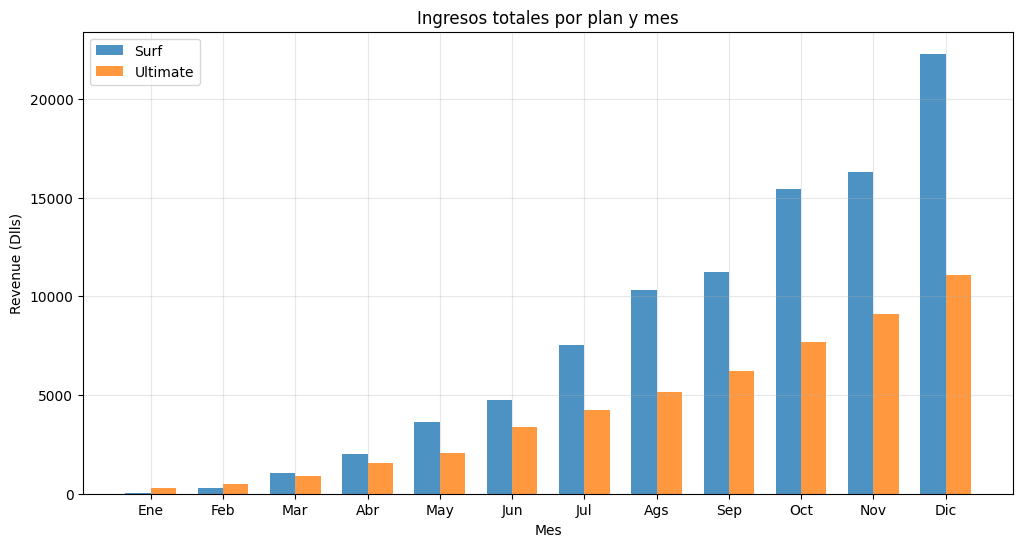

In [39]:
# Estadísticas descriptivas básicas de ingresos por plan
# Filtramos por tipo de plan y seleccionamos la columna revenue
surf_revenue = all_per_user[all_per_user['plan_name'] == 'surf']['revenue']
ultimate_revenue = all_per_user[all_per_user['plan_name'] == 'ultimate']['revenue']

#Calculamos el ingreso total del año de ambos planes
surf_sum_revenue = surf_revenue.sum()
ultimate_sum_revenue = ultimate_revenue.sum()

#Mostramos las estadisticas por Plan
print("Estadísticas de ingresos por plan:")
print("\nPlan Surf:")
print(f"El total de ingresos anual del plan surf es: {surf_sum_revenue:.2f}")
print(surf_revenue.describe())

print("\nPlan Ultimate:")
print(f"El total de ingresos anual del plan ultimate es: {ultimate_sum_revenue:.2f}")
print(ultimate_revenue.describe())

# Analizamos por medio de un grafico de barras doble los ingresos mensuales por tipo de plan
# Agrupamos por plan y mes y calculamos el total de los ingresos
ingresos_by_plan_month = all_per_user.groupby(['plan_name', 'month'])['revenue'].sum().reset_index()

# Creamos la configuración del tamaño del gráfico de barras para comparar duración promedio
plt.figure(figsize=(12, 6))

# Separamos datos por plan ya que vamos a graficar barras dobles (surf y ultimate)
surf_revenue_ = ingresos_by_plan_month[ingresos_by_plan_month['plan_name'] == 'surf']
ultimate_revenue_ = ingresos_by_plan_month[ingresos_by_plan_month['plan_name'] == 'ultimate']


# Creamos posiciones para las barras para que el rango sea del 0-11 (12 meses)
x = np.arange(len(surf_revenue_['month']))

#configuramos el ancho de la barra
width = 0.35

# creamos las barras, una para surf y otra para ultimate separados por una anchura de la barra (2 veces media anchura)
plt.bar(x - width/2, surf_revenue_['revenue'], width, label='Surf', alpha=0.8)
plt.bar(x + width/2, ultimate_revenue_['revenue'], width, label='Ultimate', alpha=0.8)

# Personalizamos el gráfico

plt.xlabel('Mes')
plt.ylabel('Revenue (Dlls)')
plt.title('Ingresos totales por plan y mes')

#agregamos los nombres de cada mes en el eje x
plt.xticks(x, ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ags','Sep','Oct','Nov','Dic'])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



In [40]:
# CONCLUSIONES #  Definitivamente los ingresos del plan Surf es mayor que Ultimate

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Correcto!

Con las gráficas utilizadas podemos ver las diferencias más marcadas entre los planes, lo que nos ayuda a tomar mejores decisiones y mejorar el negocio
</div>


## Prueba las hipótesis estadísticas

[Prueba la hipótesis de que son diferentes los ingresos promedio procedentes de los usuarios de los planes de llamada Ultimate y Surf.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [41]:
#Primero calculamos la media de cada plan para darnos una idea de lo que pasará con la hipotesis
surf_mean = all_per_user[all_per_user['plan_name']=='surf']['revenue'].mean()
ultimate_mean = all_per_user[all_per_user['plan_name']=='ultimate']['revenue'].mean()

print("La media del plan surf es:",surf_mean)
print("La media del plan ultimate es:",ultimate_mean)
print()


# Se realiza la prueba de hipotesis
alpha = 0.05
test_results = st.ttest_ind(all_per_user[all_per_user['plan_name']=='surf']['revenue'],
all_per_user[all_per_user['plan_name']=='ultimate']['revenue'])

print("Valor p de la prueba t para comparar ingresos entre planes:", test_results.pvalue)

if test_results.pvalue > alpha:
    print("No se rechaza Hipotesis Nula")
else:
    print("Se rechaza H0")



#SI EL VALOR P ES MENOR A 0.05, PODEMOS CONCLUIR QUE LOS INGRESOS PROMEDIO ENTRE LOS DOS PLANES SON SIGNIFICATIVAMENTE DIFERENTES
#SI EL VALOR P ES MAYOR A 0.05, NO HAY SUFICIENTE EVIDENCIA PARA DECIR QUE UN PLAN GENERA MAS INGRESOS QUE OTRO



La media del plan surf es: 60.32734621741895
La media del plan ultimate es: 72.31388888888888

Valor p de la prueba t para comparar ingresos entre planes: 9.342071816297584e-09
Se rechaza H0


[Prueba la hipótesis de que el ingreso promedio de los usuarios del área NY-NJ es diferente al de los usuarios de otras regiones.]

[Elabora las hipótesis nula y alternativa, escoge la prueba estadística, determina el valor alfa.]

In [42]:
# Primero tenemos que hacer un merge para agregar city al DataFrame general
# Merge para agregar solo la columna 'city' desde df_users
all_per_user = all_per_user.merge(
    df_users[['user_id', 'city']],  # Seleccionamos solo las columnas necesarias

    on='user_id',                   # Clave de unión
    how='left'                      # Conserva todos los registros de all_per_user
)

# Ahora creamos una nueva columna booleana para diferenciar los que pertenezcan a NY-NJ y los que no
all_per_user['NY_NJ'] = (all_per_user['city'] == 'New York-Newark-Jersey City, NY-NJ-PA MSA').astype(int)

#Al analisis ayudaran tener las medias sobre los que son de NY_NJ y los que no
print("Ingreso promedio NY-NJ:", all_per_user[all_per_user['NY_NJ']==1]['revenue'].mean())
print("Ingreso promedio otras ciudades:", all_per_user[all_per_user['NY_NJ']==0]['revenue'].mean())

# Prueba las hipótesis
alpha = 0.05
test_results = st.ttest_ind(all_per_user[all_per_user['NY_NJ']==1]['revenue'],
all_per_user[all_per_user['NY_NJ']==0]['revenue'])

print("Valor p de la prueba t para comparar ingresos entre NY-NJ y las demas ciudades:", test_results.pvalue)

if test_results.pvalue > alpha:
    print("No se rechaza Hipotesis Nula")
else:
    print("Se rechaza H0")

#SI EL VALOR P ES MENOR A 0.05, PODEMOS CONCLUIR QUE LOS INGRESOS PROMEDIO ENTRE NY-NJ
# y las demas ciudades SON SIGNIFICATIVAMENTE DIFERENTES
# SI EL VALOR P ES MAYOR A 0.05, NO HAY SUFICIENTE EVIDENCIA PARA DECIR QUE NY-NJ GENERA MAS INGRESOS QUE OTRAS






Ingreso promedio NY-NJ: 59.60810185676393
Ingreso promedio otras ciudades: 64.97320521920668
Valor p de la prueba t para comparar ingresos entre NY-NJ y las demas ciudades: 0.04073944362703164
Se rechaza H0


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!

La aplicación de las pruebas de hipotesis me parece acertada, seleccionando los datos y valores correctos
</div>


## Conclusión general



In [ ]:
# El análisis revela que, aunque el comportamiento de uso (llamadas, mensajes e internet) es similar entre planes, 
# los límites más bajos del plan Surf hacen que sus usuarios paguen más extras, lo que sugiere una oportunidad 
# comercial clara para migrarlos al plan Ultimate.
# Además, se evidencian diferencias significativas en los ingresos tanto entre planes como entre regiones, 
# siendo Ultimate y las ciudades fuera de NY-NJ los grupos más rentables.

## Comentario general del revisor
<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Has realizado un muy buen trabajo al desarrollar este proyecto, las observaciones que has hecho a lo largo del mismo han servido para tomar acción en los pasos posteriores, terminando en resultados positivos.

Este es un proyecto que nos adentra mucho en los analisis que se hacen recurrentemente en las compañías donde se obtiene información para tomar decisiones sobre el negocio que impactan directamente los ingresos, lo has hecho bastante bien!

Continúa con el buen trabajo y mucho éxito en el siguiente Sprint!    
</div>


<div class="alert alert-block alert-success">
<b>Aspectos positivos del proyecto</b> <a class="tocSkip"></a><br />

- Las observaciones intermedias, así como las conclusiones finales me parecen buenas
    
</div>

<div class="alert alert-block alert-warning">
<b>Aspectos que pueden mejorar del proyecto</b> <a class="tocSkip"></a><br />

- Tener mayor orden en el proyecto, mostrar la información en sus secciones respectivas
- Utilizar markdown para mejorar la presentación de las conclusiones finales    

</div>


